In [1]:
import pyomo.environ as pyo

In [ ]:
# Pyomo modélise des problèmes d'optimisation linéaires et non linéaires
print(pyomo.version.version)

In [ ]:

model = pyo.ConcreteModel()

# 4 variables continues bornées entre 1 et 5, avec un point de départ
model.x1 = pyo.Var(bounds=(1, 5), initialize=1)
model.x2 = pyo.Var(bounds=(1, 5), initialize=5)
model.x3 = pyo.Var(bounds=(1, 5), initialize=5)
model.x4 = pyo.Var(bounds=(1, 5), initialize=1)

# Objectif non linéaire
model.obj = pyo.Objective(
    expr=model.x1 * model.x4 * (model.x1 + model.x2 + model.x3) + model.x3,
    sense=pyo.minimize,
)

# Contrainte d'inégalité non linéaire : produit >= 25
model.c1 = pyo.Constraint(expr=model.x1 * model.x2 * model.x3 * model.x4 >= 25)

# Contrainte d'égalité non linéaire : somme des carrés = 40
model.c2 = pyo.Constraint(
    expr=model.x1**2 + model.x2**2 + model.x3**2 + model.x4**2 == 40
)

solver = pyo.SolverFactory("ipopt")
# ipopt est un solveur de points intérieurs, pour problèmes non linéaires
if not solver.available():
    raise RuntimeError("Ipopt n'est pas trouvé : vérifie son installation et le PATH.")

resultat = solver.solve(model, tee=False)

print("Statut :", resultat.solver.termination_condition)
for v in (model.x1, model.x2, model.x3, model.x4):
    print(f"{v.name} = {pyo.value(v):.4f}")
print(f"Objectif = {pyo.value(model.obj):.4f}")

n =   10 -> 0.029 s
n =   15 -> 0.079 s
n =   20 -> 0.062 s
n =   25 -> 0.038 s
n =   30 -> 0.155 s
n =   35 -> 0.059 s
n =   40 -> 0.751 s
n =   45 -> 1.535 s
n =   50 -> 2.032 s
n =   55 -> 2.403 s
n =   60 -> 0.687 s
n =   65 -> 0.734 s


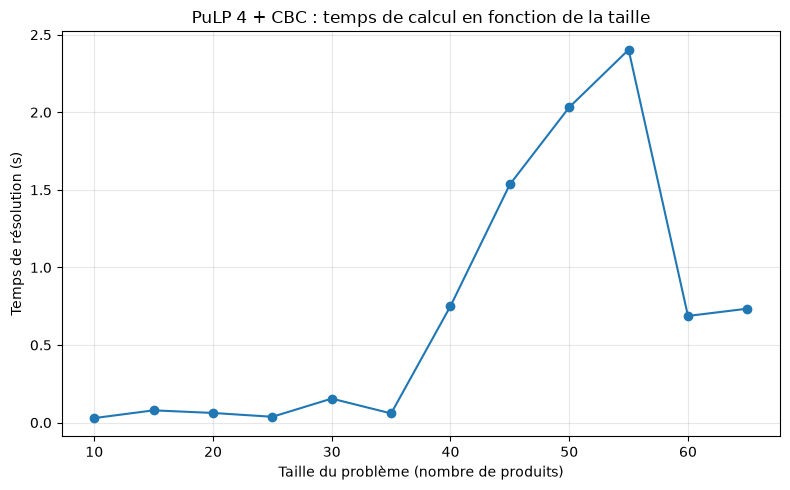

obj_lp=1121.3558 | obj_int 1115 | obj_cp 1115
n=  10 | CBC 0.008s | LP 0.005s | CP-SAT 0.007s | écart LP 0.4228 %
obj_lp=2944.5155 | obj_int 2934 | obj_cp 2934
n=  20 | CBC 0.063s | LP 0.005s | CP-SAT 0.013s | écart LP 0.4604 %
obj_lp=3869.2249 | obj_int 3854 | obj_cp 3854
n=  30 | CBC 0.153s | LP 0.005s | CP-SAT 0.069s | écart LP 0.3950 %
obj_lp=5521.4215 | obj_int 5507 | obj_cp 5507
n=  40 | CBC 0.222s | LP 0.005s | CP-SAT 0.114s | écart LP 0.2619 %
obj_lp=6737.3480 | obj_int 6721 | obj_cp 6721
n=  50 | CBC 0.630s | LP 0.006s | CP-SAT 1.168s | écart LP 0.2305 %
obj_lp=7947.9657 | obj_int 7935 | obj_cp 7935
n=  60 | CBC 1.548s | LP 0.006s | CP-SAT 2.030s | écart LP 0.2142 %


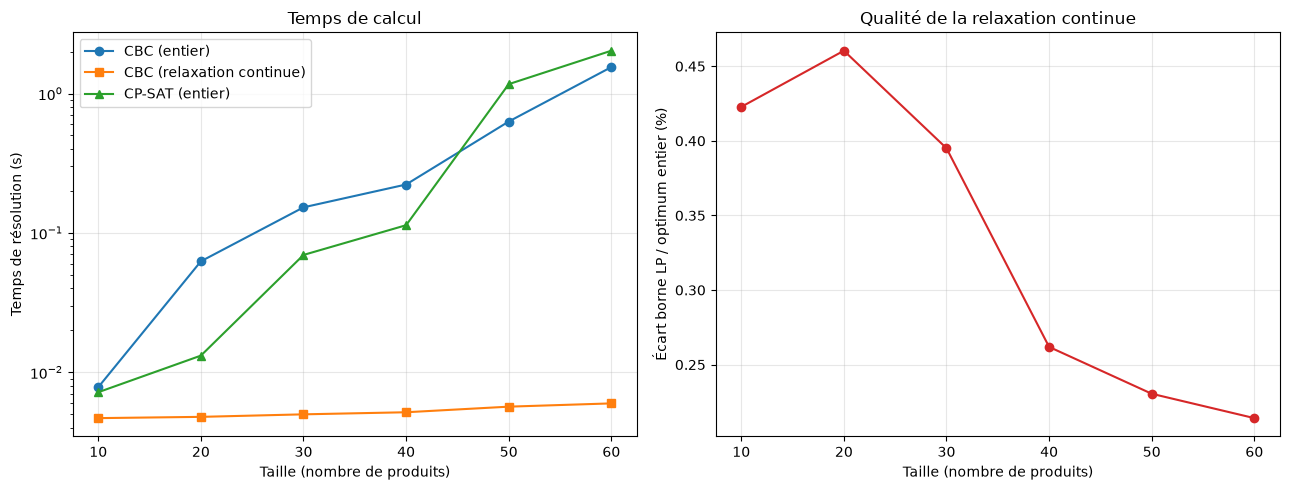